
# VQE para TSP — análise experimental em PT-BR

Este notebook organiza o projeto como um **estudo experimental**, e não apenas como uma execução única.

## Diagnóstico principal antes dos experimentos
No notebook anterior havia um problema importante: o circuito usado no treinamento (`energy_qnode`) **não era o mesmo** do circuito usado na decodificação (`probs_qnode`), porque o treinamento aplicava uma camada de Hadamards e a etapa de probabilidade não aplicava. Isso tornava a leitura do melhor bitstring inconsistente.

Neste notebook:

- o **mesmo preparo de estado** é usado para energia, amostragem e visualização;
- a decodificação é feita preferencialmente por **amostragem/contagens**, evitando `qml.probs()` em muitos qubits;
- os resultados são analisados sob variação de:
  1. **otimizador**;
  2. **número de iterações**;
  3. **Hamiltoniano** (pesos de penalidade e escala da parte de distância).

## Leitura correta do que está acontecendo
Se o algoritmo continuar retornando soluções inválidas, isso normalmente indica uma combinação de fatores:
- paisagem de otimização difícil;
- ansatz genérico pouco alinhado ao problema;
- penalidades mal escaladas;
- distribuição final muito espalhada, em vez de concentrada em um único bitstring factível.

O objetivo deste notebook é **medir isso explicitamente**, e não apenas “tentar valores maiores de A”.



## 0) Dependências

Se necessário:

```bash
pip install pennylane pennylane-lightning torch matplotlib pandas networkx
```


In [1]:

import itertools
import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pennylane as qml
import torch

print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)
print("CUDA disponível no Torch:", torch.cuda.is_available())


PennyLane: 0.44.0
Torch: 2.10.0+cu128
CUDA disponível no Torch: True



## 1) Configuração e geração da instância do TSP

Para análise, é recomendável começar com **4 cidades**.  
Com 5 cidades temos \(n^2=25\) qubits, e a leitura por probabilidades completas passa a ter tamanho \(2^{25}\), o que cresce muito rápido.


In [2]:

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Comece com 4 para validação mais estável; depois teste 5.
NUM_CIDADES = 5

# Coordenadas aleatórias no plano
cities = np.random.rand(NUM_CIDADES, 2) * 10.0

def build_distance_matrix(cities: np.ndarray) -> np.ndarray:
    """Constrói a matriz simétrica de distâncias euclidianas entre as cidades."""
    n = len(cities)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j:
                D[i, j] = np.linalg.norm(cities[i] - cities[j])
    return D

D = build_distance_matrix(cities)
n = D.shape[0]
n_qubits = n * n

print("Número de cidades:", n)
print("Número de qubits:", n_qubits)
print("d_max =", D.max())
D


Número de cidades: 5
Número de qubits: 25
d_max = 8.242154905735049


array([[0.        , 5.01713601, 8.24215491, 3.27553692, 3.31980708],
       [5.01713601, 0.        , 7.2642889 , 7.25066088, 1.70589385],
       [8.24215491, 7.2642889 , 0.        , 7.16902511, 7.09155104],
       [3.27553692, 7.25066088, 7.16902511, 0.        , 5.65579207],
       [3.31980708, 1.70589385, 7.09155104, 5.65579207, 0.        ]])

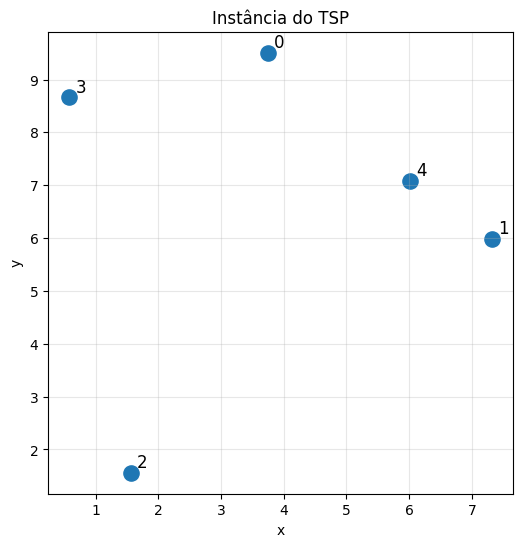

In [3]:

def plot_tsp_instance(cities: np.ndarray, route=None, title="Instância do TSP"):
    """Plota as cidades e, opcionalmente, uma rota fechada."""
    plt.figure(figsize=(6, 6))
    plt.scatter(cities[:, 0], cities[:, 1], s=120)

    for i, (x, y) in enumerate(cities):
        plt.text(x + 0.1, y + 0.1, str(i), fontsize=12)

    if route is not None:
        route = list(route)
        for t in range(len(route)):
            a = route[t]
            b = route[(t + 1) % len(route)]
            plt.plot([cities[a, 0], cities[b, 0]], [cities[a, 1], cities[b, 1]], linewidth=2)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.3)
    plt.show()

plot_tsp_instance(cities)



## 2) Codificação binária \(x_{i,t}\)

Usamos a codificação padrão:

- \(x_{i,t}=1\): a cidade **i** é visitada no passo **t**;
- cada solução candidata tem \(n^2\) variáveis binárias;
- cada variável binária vira um qubit após o mapeamento para Ising/Pauli-Z.


In [4]:

def qindex(i: int, t: int, n: int) -> int:
    """Mapeia (cidade i, tempo t) para o índice do qubit em [0, n²-1]."""
    return i * n + t



## 3) Construção do QUBO do TSP

Hamiltoniano clássico total:

\[
H = H_{dist} + A_{city} H_{city} + A_{time} H_{time}
\]

com:

\[
H_{dist} = \sum_{t=0}^{n-1}\sum_{i,j} d_{ij} \, x_{i,t}x_{j,(t+1 \bmod n)}
\]

\[
H_{city} = \sum_i \left(\sum_t x_{i,t} - 1\right)^2
\]

\[
H_{time} = \sum_t \left(\sum_i x_{i,t} - 1\right)^2
\]

Nesta versão, permitimos variar:
- `A_city`
- `A_time`
- `distance_scale`

Isso facilita o estudo de “mudanças no Hamiltoniano”.


In [5]:

def add_qubo_term(Q: dict, a: int, b: int, coeff: float):
    """Acumula o coeficiente do termo x_a x_b no dicionário QUBO, usando a <= b."""
    if a > b:
        a, b = b, a
    Q[(a, b)] = Q.get((a, b), 0.0) + float(coeff)

def build_tsp_qubo(
    D: np.ndarray,
    A_city: float,
    A_time: float,
    distance_scale: float = 1.0,
):
    """Constrói o QUBO do TSP com penalidades separadas para cidade e tempo.

    Retorna:
        Q: dicionário {(a,b): coeficiente}
        const: deslocamento constante vindo da expansão dos termos quadráticos
    """
    n = D.shape[0]
    Q = {}
    const = 0.0

    # Parte de distância
    for t in range(n):
        tp1 = (t + 1) % n
        for i in range(n):
            a = qindex(i, t, n)
            for j in range(n):
                b = qindex(j, tp1, n)
                add_qubo_term(Q, a, b, distance_scale * D[i, j])

    # Restrição: cada cidade aparece exatamente uma vez
    for i in range(n):
        const += A_city
        for t in range(n):
            a = qindex(i, t, n)
            add_qubo_term(Q, a, a, -A_city)
        for t in range(n):
            for u in range(t + 1, n):
                a = qindex(i, t, n)
                b = qindex(i, u, n)
                add_qubo_term(Q, a, b, 2.0 * A_city)

    # Restrição: em cada tempo, exatamente uma cidade
    for t in range(n):
        const += A_time
        for i in range(n):
            a = qindex(i, t, n)
            add_qubo_term(Q, a, a, -A_time)
        for i in range(n):
            for j in range(i + 1, n):
                a = qindex(i, t, n)
                b = qindex(j, t, n)
                add_qubo_term(Q, a, b, 2.0 * A_time)

    return Q, const



## 4) Mapeamento QUBO → Ising → Hamiltoniano Pauli-Z

Usamos:

\[
x = \frac{1 - Z}{2}
\]

Com isso, cada termo do QUBO é convertido em combinação de:
- identidade \(I\),
- termos lineares \(Z_i\),
- termos quadráticos \(Z_i Z_j\).

O resultado é um `qml.Hamiltonian`.


In [6]:

def qubo_to_ising_hamiltonian(Q: dict, n_qubits: int):
    """Converte o QUBO em um Hamiltoniano de Pauli-Z.

    Retorna:
        H: Hamiltoniano do PennyLane
        const: deslocamento constante do mapeamento
    """
    coeffs = []
    ops = []
    const = 0.0

    def add_op(c, op):
        if abs(c) > 1e-12:
            coeffs.append(float(c))
            ops.append(op)

    for (a, b), c in Q.items():
        if a == b:
            const += c / 2.0
            add_op(-c / 2.0, qml.PauliZ(a))
        else:
            const += c / 4.0
            add_op(-c / 4.0, qml.PauliZ(a))
            add_op(-c / 4.0, qml.PauliZ(b))
            add_op(c / 4.0, qml.PauliZ(a) @ qml.PauliZ(b))

    H = qml.Hamiltonian(coeffs, ops)
    return H, const



## 5) Utilidades clássicas de validação

Estas funções servem para:
- calcular energia clássica do QUBO;
- converter bitstring em matriz \(x\);
- checar factibilidade;
- decodificar rota;
- comparar com a solução ótima por força bruta.


Ótimo por força bruta: (0, 3, 2, 1, 4) | distância = 22.734551867849092


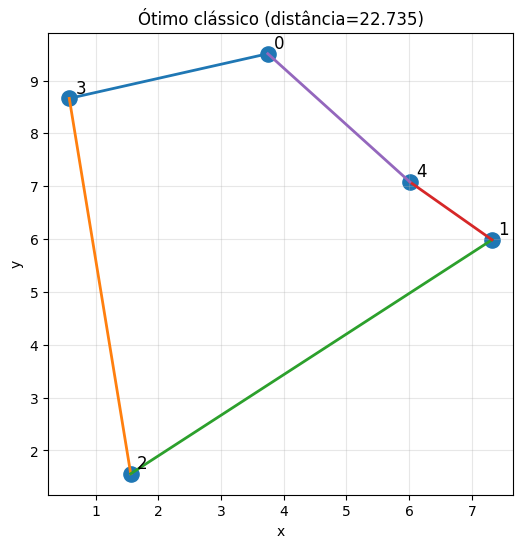

In [7]:

def bitstring_to_x(bitstring: np.ndarray, n: int) -> np.ndarray:
    """Reorganiza o bitstring plano em matriz n x n, com linhas= cidades e colunas= tempos."""
    return bitstring.reshape(n, n)

def x_to_route(x: np.ndarray):
    """Decodifica uma rota usando argmax em cada coluna.

    Observação:
        Se a matriz não for válida, essa rota é apenas uma aproximação de leitura,
        não uma solução correta do TSP.
    """
    route = []
    for t in range(x.shape[1]):
        route.append(int(np.argmax(x[:, t])))
    return route

def route_distance(route, D: np.ndarray) -> float:
    """Calcula a distância total de uma rota fechada."""
    dist = 0.0
    n = len(route)
    for t in range(n):
        i = route[t]
        j = route[(t + 1) % n]
        dist += D[i, j]
    return float(dist)

def qubo_energy(Q: dict, const: float, xvec: np.ndarray) -> float:
    """Calcula a energia clássica do QUBO para um vetor binário x."""
    E = const
    for (a, b), c in Q.items():
        E += c * xvec[a] * xvec[b]
    return float(E)

def feasibility_metrics(x: np.ndarray):
    """Retorna somas por linha e coluna e um indicador booleano de validade."""
    row_sums = x.sum(axis=1)
    col_sums = x.sum(axis=0)
    valid = np.all(row_sums == 1) and np.all(col_sums == 1)
    return row_sums, col_sums, bool(valid)

def brute_force_tsp(D: np.ndarray):
    """Resolve exatamente o TSP por força bruta para instâncias pequenas."""
    n = D.shape[0]
    best = None
    best_dist = float("inf")
    cities = list(range(n))
    for perm in itertools.permutations(cities[1:]):
        route = (0,) + perm
        d = route_distance(route, D)
        if d < best_dist:
            best_dist = d
            best = route
    return best, best_dist

opt_route, opt_dist = brute_force_tsp(D)
print("Ótimo por força bruta:", opt_route, "| distância =", opt_dist)
plot_tsp_instance(cities, opt_route, title=f"Ótimo clássico (distância={opt_dist:.3f})")



## 6) Escolha do device

Tentamos usar `lightning.gpu` e, se não estiver disponível, caímos para `lightning.qubit`.


In [8]:

device_name = "lightning.gpu"
try:
    dev = qml.device(device_name, wires=n_qubits, shots=None)
    print(f"Usando device: {device_name}")
except Exception as e:
    device_name = "lightning.qubit"
    dev = qml.device(device_name, wires=n_qubits, shots=None)
    print(f"Usando fallback: {device_name} | motivo: {type(e).__name__}: {e}")


Usando device: lightning.gpu



## 7) Preparo de estado compartilhado

Aqui está a correção central do notebook:

- o **mesmo circuito** é usado para energia;
- o **mesmo circuito** é usado para amostragem/contagens;
- o **mesmo circuito** é usado para visualização.

Assim, a leitura do bitstring final fica consistente com o que foi treinado.


In [9]:

def prepare_state(weights: torch.Tensor, use_hadamard_init: bool = True):
    """Prepara o estado variacional usado em todas as etapas.

    Parâmetros:
        weights: parâmetros treináveis do ansatz
        use_hadamard_init: se True, aplica Hadamard em todos os qubits antes do ansatz
    """
    if use_hadamard_init:
        for w in range(n_qubits):
            qml.Hadamard(wires=w)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))


In [10]:

def make_energy_qnode(dev, H, use_hadamard_init=True):
    """Cria um QNode para avaliar a energia esperada do Hamiltoniano."""
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def energy_qnode(weights):
        prepare_state(weights, use_hadamard_init=use_hadamard_init)
        return qml.expval(H)
    return energy_qnode

def make_counts_qnode(n_qubits: int, shots: int, use_hadamard_init=True):
    """Cria um QNode de contagens para decodificar bitstrings por amostragem.

    Usamos um device separado com shots finitos.
    """
    sample_dev = qml.device("default.qubit", wires=n_qubits, shots=shots)

    @qml.qnode(sample_dev, interface="torch")
    def counts_qnode(weights):
        prepare_state(weights, use_hadamard_init=use_hadamard_init)
        return qml.counts(wires=range(n_qubits))
    return counts_qnode



## 8) Visualização do circuito

O PennyLane oferece `qml.draw()` e `qml.draw_mpl()` para inspecionar o circuito.  
Aqui criamos um helper para desenhar o circuito correspondente a cada configuração do estudo.


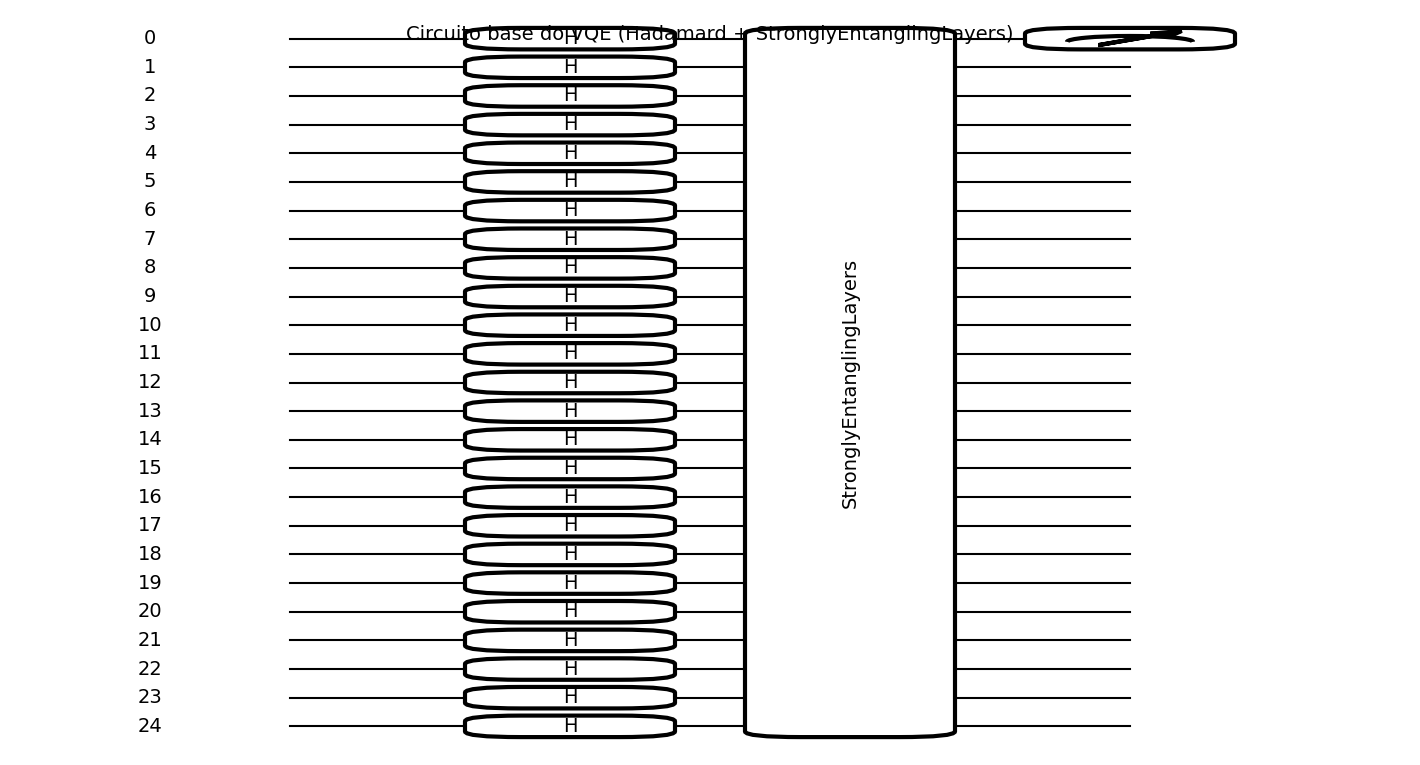

In [11]:

def plot_circuit_example(weights_shape, title, use_hadamard_init=True):
    """Plota uma visualização do circuito para um formato de pesos específico."""
    dummy = np.zeros(weights_shape, dtype=float)

    @qml.qnode(qml.device("default.qubit", wires=n_qubits))
    def circuit_for_plot(weights):
        prepare_state(weights, use_hadamard_init=use_hadamard_init)
        return qml.expval(qml.PauliZ(0))

    fig, ax = qml.draw_mpl(circuit_for_plot)(dummy)
    fig.set_size_inches(14, min(18, 1.2 + 0.25 * n_qubits))
    fig.suptitle(title, fontsize=14)
    plt.show()

# Exemplo do circuito base
plot_circuit_example(
    weights_shape=(2, n_qubits, 3),
    title="Circuito base do VQE (Hadamard + StronglyEntanglingLayers)",
    use_hadamard_init=True,
)



## 9) Função de treino do VQE

Esta função recebe:
- Hamiltoniano;
- nome do otimizador;
- taxa de aprendizado;
- número de camadas;
- número de passos;
- número de reinicializações (`restarts`).

No final, ela avalia a solução por **contagens**, não por `qml.probs()`.


In [12]:

def make_torch_optimizer(name: str, params, lr: float):
    """Fábrica simples de otimizadores do PyTorch."""
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr)
    raise ValueError(f"Otimizador não suportado: {name}")

def counts_to_best_bitstring(counts_dict, n_qubits: int):
    """Converte o resultado de `qml.counts` no bitstring mais frequente."""
    # Chaves podem vir como strings do tipo '0101...'
    best_key = max(counts_dict, key=counts_dict.get)
    if isinstance(best_key, str):
        bitstring = np.array([int(ch) for ch in best_key], dtype=int)
    else:
        # fallback conservador
        bitstring = np.array(list(np.binary_repr(int(best_key), width=n_qubits)), dtype=int)
    return bitstring, counts_dict[best_key]

def run_vqe_experiment(
    D: np.ndarray,
    A_city: float,
    A_time: float,
    distance_scale: float,
    optimizer_name: str,
    lr: float,
    n_layers: int,
    steps: int,
    restarts: int = 5,
    use_hadamard_init: bool = True,
    sample_shots: int = 2048,
    verbose: bool = False,
):
    """Executa um experimento de VQE e retorna métricas resumidas."""
    n = D.shape[0]
    n_qubits = n * n

    Q, const_qubo = build_tsp_qubo(
        D,
        A_city=A_city,
        A_time=A_time,
        distance_scale=distance_scale,
    )
    H, const_ising = qubo_to_ising_hamiltonian(Q, n_qubits)
    energy_qnode = make_energy_qnode(dev, H, use_hadamard_init=use_hadamard_init)
    counts_qnode = make_counts_qnode(n_qubits, sample_shots, use_hadamard_init=use_hadamard_init)

    best_final_energy = float("inf")
    best_weights = None
    best_history = None
    best_restart = None

    for restart in range(restarts):
        torch.manual_seed(1000 + restart)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(1000 + restart)

        weights = torch.nn.Parameter(
            0.10 * torch.randn(n_layers, n_qubits, 3, dtype=torch.float64)
        )
        opt = make_torch_optimizer(optimizer_name, [weights], lr=lr)

        history = []
        for step in range(steps):
            opt.zero_grad(set_to_none=True)
            E = energy_qnode(weights)
            E.backward()
            opt.step()
            history.append(float(E.detach().cpu()))

        final_energy = float(energy_qnode(weights).detach().cpu())

        if final_energy < best_final_energy:
            best_final_energy = final_energy
            best_weights = weights.detach().clone()
            best_history = history
            best_restart = restart

    counts = counts_qnode(best_weights)
    # Converter OrderedDict-like para dict puro
    counts = dict(counts)
    best_bitstring, best_count = counts_to_best_bitstring(counts, n_qubits=n_qubits)
    x = bitstring_to_x(best_bitstring, n)
    row_sums, col_sums, valid = feasibility_metrics(x)
    route = x_to_route(x)
    decoded_distance = route_distance(route, D)

    E_best_sample = qubo_energy(Q, const_qubo, best_bitstring)

    result = {
        "optimizer": optimizer_name,
        "lr": lr,
        "n_layers": n_layers,
        "steps": steps,
        "restarts": restarts,
        "A_city": A_city,
        "A_time": A_time,
        "distance_scale": distance_scale,
        "best_restart": best_restart,
        "final_energy": best_final_energy,
        "best_count": int(best_count),
        "sample_shots": sample_shots,
        "valid": valid,
        "decoded_route": route,
        "decoded_distance": decoded_distance,
        "qubo_energy_best_bitstring": E_best_sample,
        "row_sums": row_sums.tolist(),
        "col_sums": col_sums.tolist(),
        "x_matrix": x.copy(),
        "best_bitstring": best_bitstring.copy(),
        "energy_history": best_history,
    }
    return result



## 10) Execução de referência

Antes dos estudos paramétricos, faça uma execução de referência para verificar:

- se o circuito agora é coerente entre treino e leitura;
- se o bitstring mais frequente é factível;
- se a distância decodificada se aproxima do ótimo clássico.


In [13]:

# Heurística inicial para penalidades:
# usar algo da ordem de n * d_max costuma ser um ponto de partida razoável.
d_max = D.max()
A_base = n * d_max

baseline = run_vqe_experiment(
    D=D,
    A_city=A_base,
    A_time=A_base,
    distance_scale=1.0,
    optimizer_name="adam",
    lr=0.02,
    n_layers=2,
    steps=250,
    restarts=5,
    use_hadamard_init=True,
    sample_shots=2048,
)

baseline


/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


{'optimizer': 'adam',
 'lr': 0.02,
 'n_layers': 2,
 'steps': 250,
 'restarts': 5,
 'A_city': np.float64(41.210774528675245),
 'A_time': np.float64(41.210774528675245),
 'distance_scale': 1.0,
 'best_restart': 4,
 'final_energy': -1333.44580078125,
 'best_count': 530,
 'sample_shots': 2048,
 'valid': False,
 'decoded_route': [0, 0, 1, 4, 2],
 'decoded_distance': 22.056735802921285,
 'qubo_energy_best_bitstring': 206.357360705637,
 'row_sums': [2, 1, 1, 2, 1],
 'col_sums': [1, 2, 2, 1, 1],
 'x_matrix': array([[1, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 1, 1, 0, 0],
        [0, 0, 0, 1, 0]]),
 'best_bitstring': array([1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
        0, 1, 0]),
 'energy_history': [3.3067190647125244,
  -3.79455828666687,
  -10.773594856262207,
  -17.709346771240234,
  -24.627540588378906,
  -31.544334411621094,
  -38.50315475463867,
  -45.558380126953125,
  -52.76091003417969,
  -60.1385498046875,
  -67.7015762329

Validade: False
Somas por linha: [2, 1, 1, 2, 1]
Somas por coluna: [1, 2, 2, 1, 1]
Rota decodificada: [0, 0, 1, 4, 2]
Distância decodificada: 22.056735802921285
Ótimo clássico: (0, 3, 2, 1, 4) | 22.734551867849092


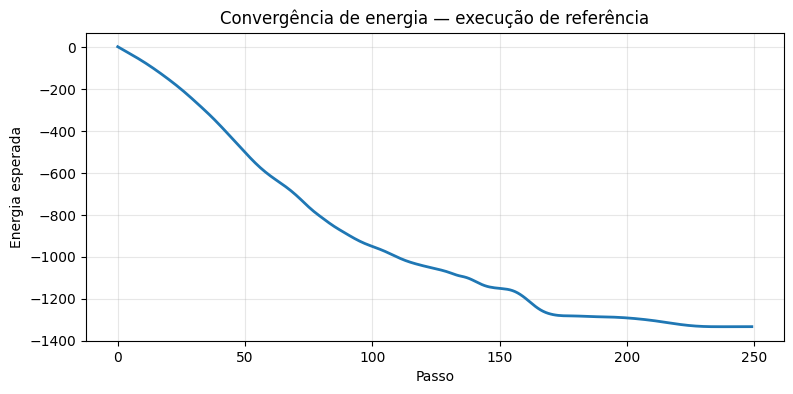

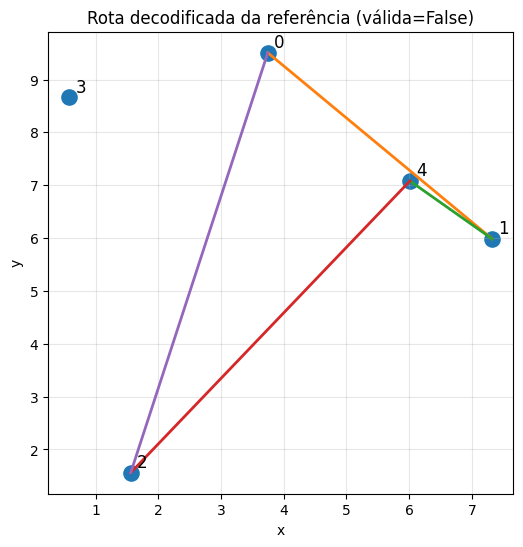

In [14]:

print("Validade:", baseline["valid"])
print("Somas por linha:", baseline["row_sums"])
print("Somas por coluna:", baseline["col_sums"])
print("Rota decodificada:", baseline["decoded_route"])
print("Distância decodificada:", baseline["decoded_distance"])
print("Ótimo clássico:", opt_route, "|", opt_dist)

plt.figure(figsize=(9, 4))
plt.plot(baseline["energy_history"], linewidth=2)
plt.title("Convergência de energia — execução de referência")
plt.xlabel("Passo")
plt.ylabel("Energia esperada")
plt.grid(alpha=0.3)
plt.show()

plot_tsp_instance(
    cities,
    baseline["decoded_route"],
    title=f"Rota decodificada da referência (válida={baseline['valid']})",
)



## 11) Estudo 1 — tipo de otimizador

Agora variamos o **otimizador**, mantendo o restante fixo.

Objetivo da análise:
- verificar estabilidade;
- comparar energia final;
- comparar taxa de factibilidade;
- observar se algum otimizador concentra melhor a distribuição.


In [15]:

optimizer_grid = [
    {"optimizer_name": "adam", "lr": 0.02},
    {"optimizer_name": "rmsprop", "lr": 0.01},
    {"optimizer_name": "sgd", "lr": 0.005},
]

results_optimizer = []

for cfg in optimizer_grid:
    print("Rodando:", cfg)
    res = run_vqe_experiment(
        D=D,
        A_city=A_base,
        A_time=A_base,
        distance_scale=1.0,
        optimizer_name=cfg["optimizer_name"],
        lr=cfg["lr"],
        n_layers=2,
        steps=250,
        restarts=5,
        use_hadamard_init=True,
        sample_shots=2048,
    )
    results_optimizer.append(res)

df_optimizer = pd.DataFrame([
    {
        "otimizador": r["optimizer"],
        "lr": r["lr"],
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    }
    for r in results_optimizer
])

df_optimizer


Rodando: {'optimizer_name': 'adam', 'lr': 0.02}


/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Rodando: {'optimizer_name': 'rmsprop', 'lr': 0.01}
Rodando: {'optimizer_name': 'sgd', 'lr': 0.005}


,otimizador,lr,energia_final,valido,distancia_decodificada,melhor_contagem
0,adam,0.020,-1333.445801,False,28.687785,543
1,rmsprop,0.010,-1226.065063,False,33.024767,149
2,sgd,0.005,-901.068848,False,22.056736,366


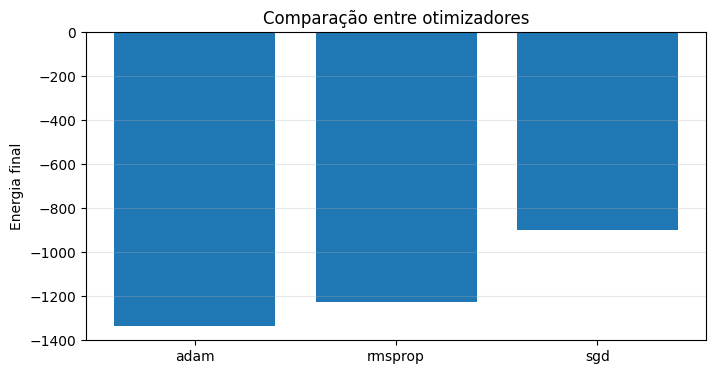

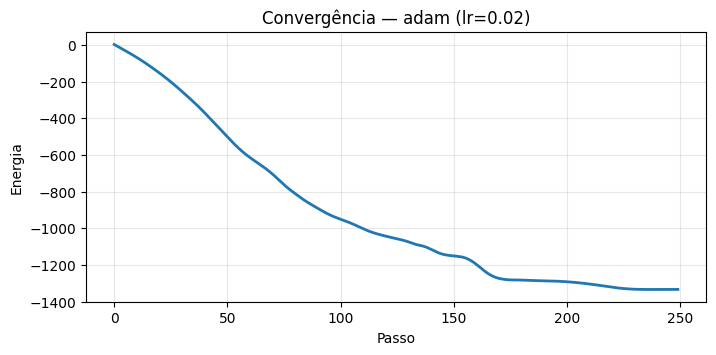

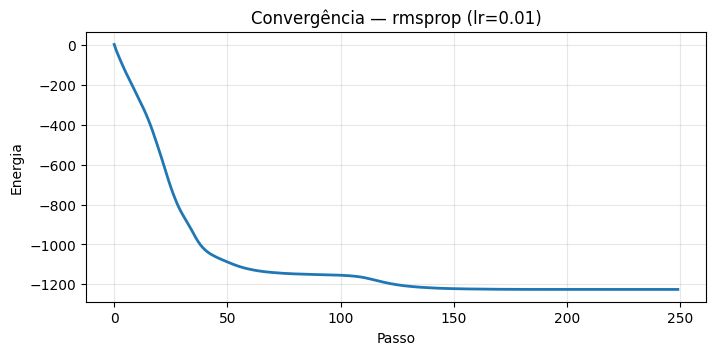

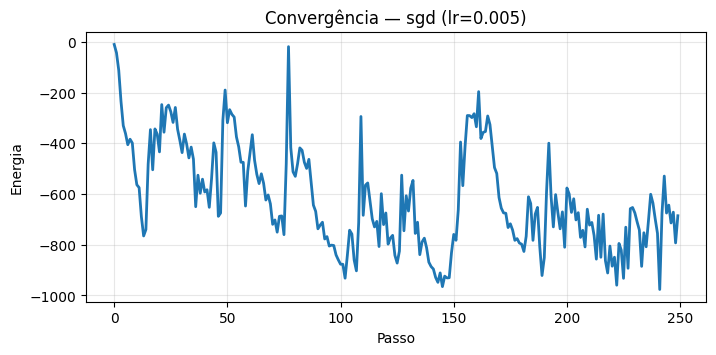

In [16]:

plt.figure(figsize=(8, 4))
plt.bar(df_optimizer["otimizador"], df_optimizer["energia_final"])
plt.title("Comparação entre otimizadores")
plt.ylabel("Energia final")
plt.grid(axis="y", alpha=0.3)
plt.show()

for r in results_optimizer:
    plt.figure(figsize=(8, 3.5))
    plt.plot(r["energy_history"], linewidth=2)
    plt.title(f"Convergência — {r['optimizer']} (lr={r['lr']})")
    plt.xlabel("Passo")
    plt.ylabel("Energia")
    plt.grid(alpha=0.3)
    plt.show()


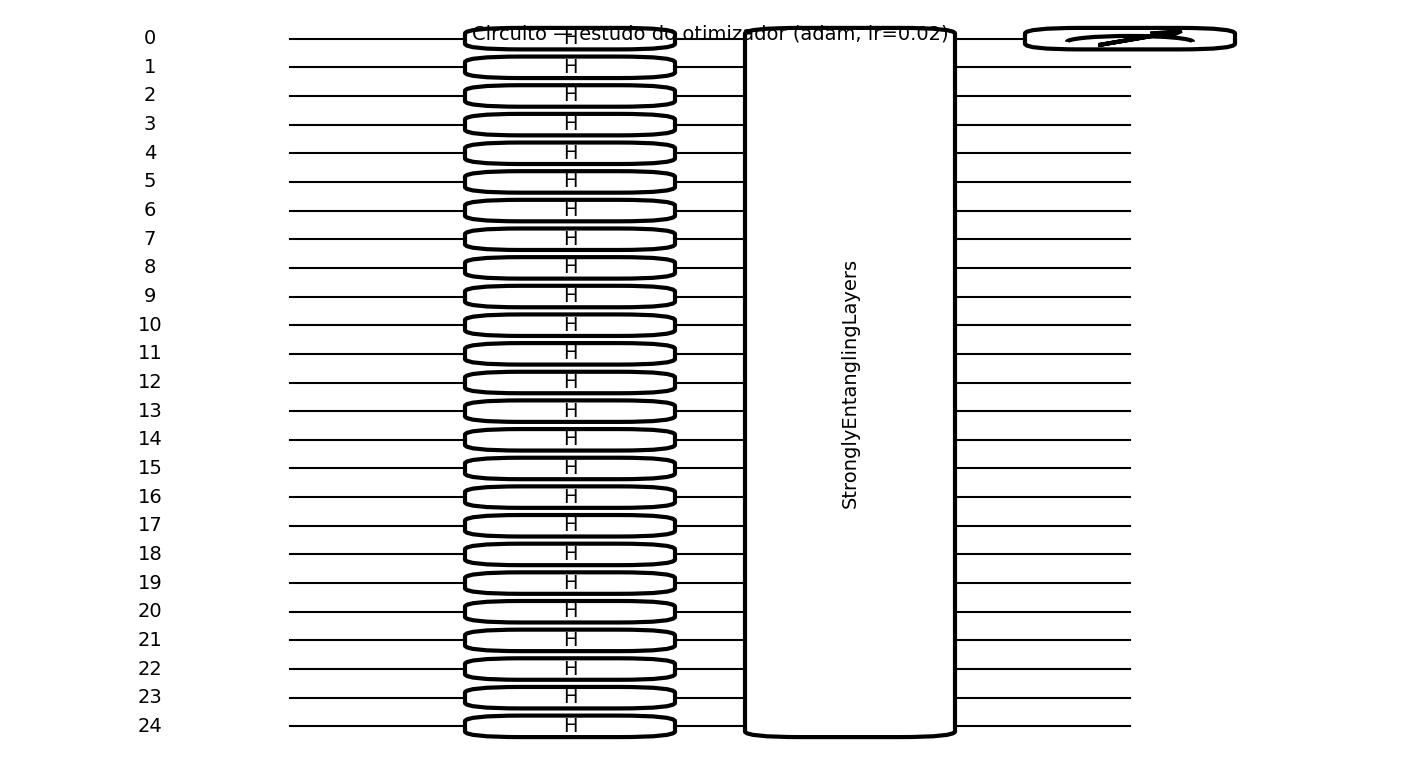

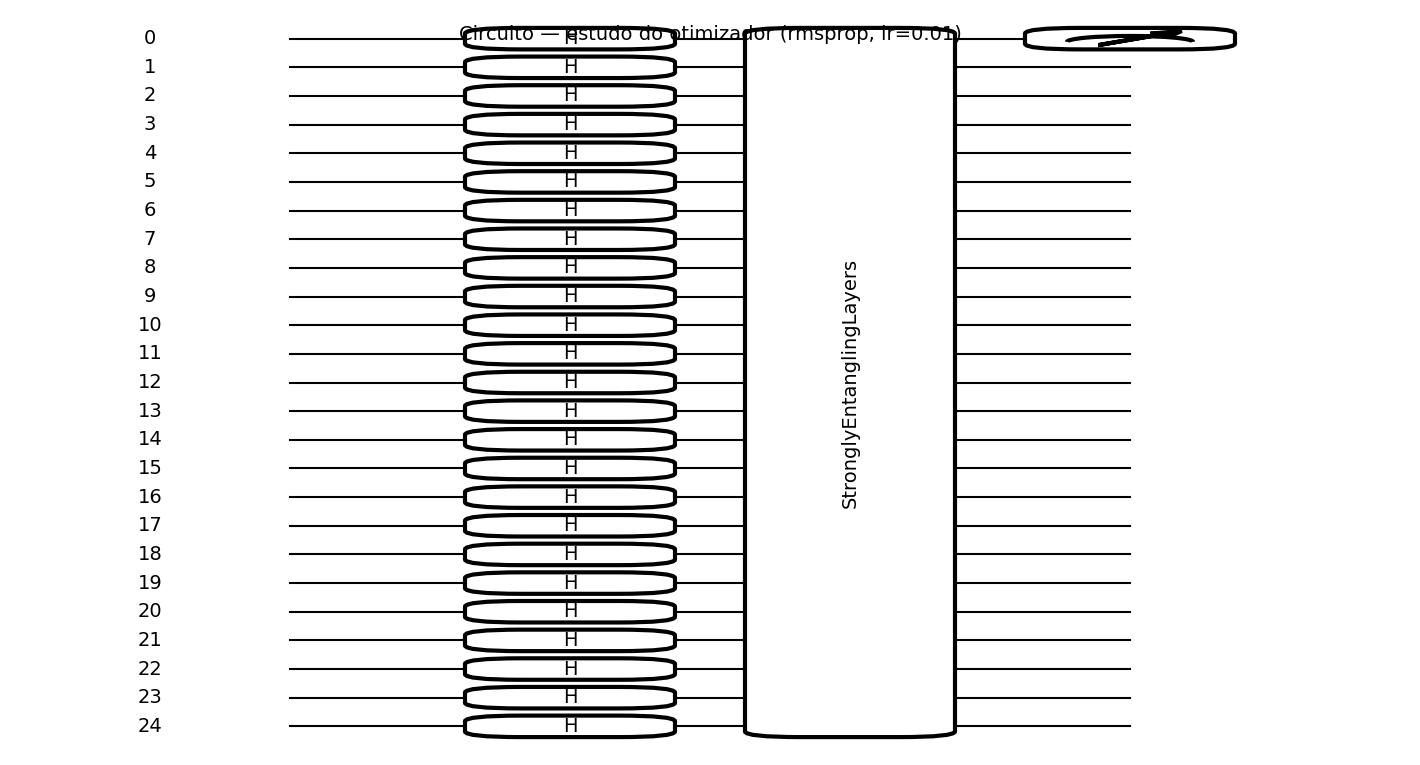

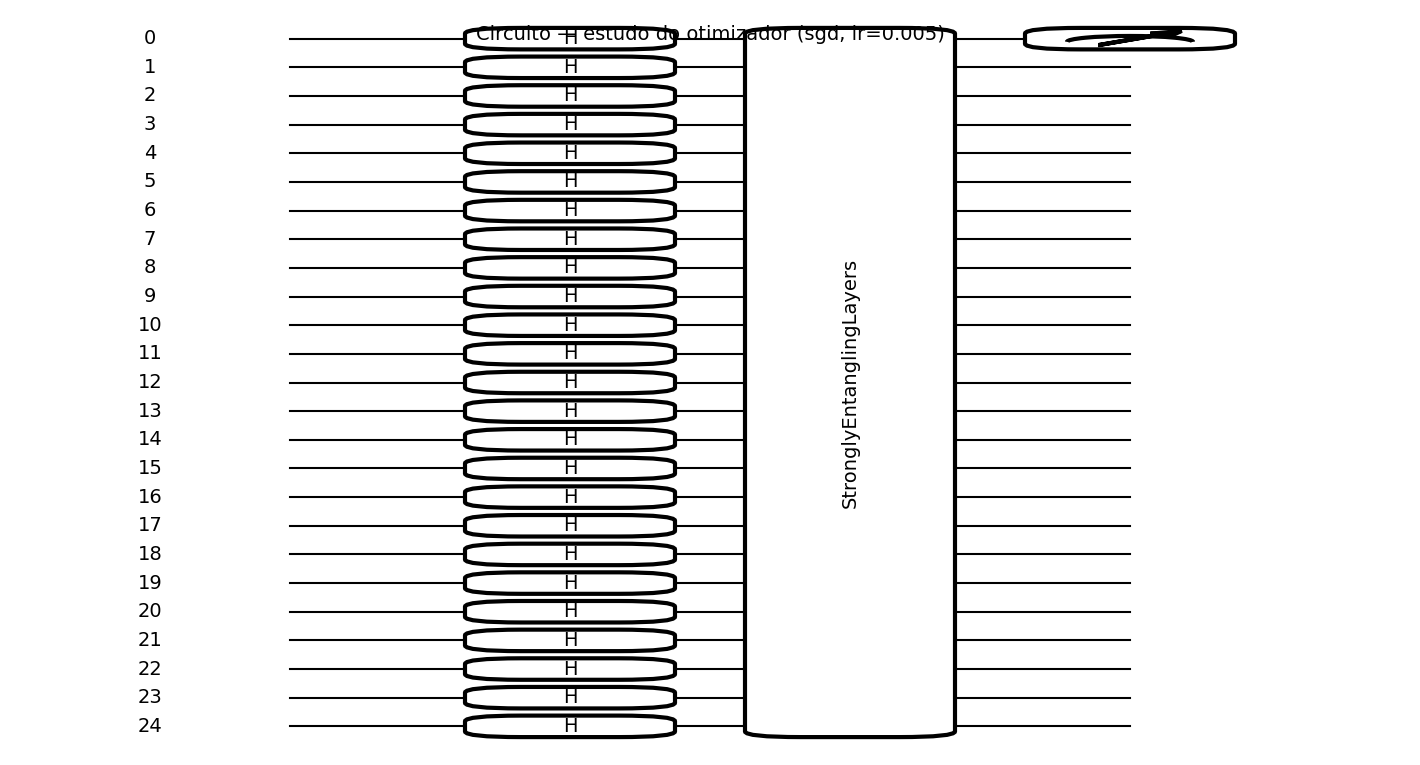

In [17]:

for cfg in optimizer_grid:
    plot_circuit_example(
        weights_shape=(2, n_qubits, 3),
        title=f"Circuito — estudo do otimizador ({cfg['optimizer_name']}, lr={cfg['lr']})",
        use_hadamard_init=True,
    )



### Como interpretar o estudo do otimizador

- Se um otimizador atinge energia menor, mas continua gerando soluções inválidas, isso indica que ele está descendo melhor a energia, porém o **Hamiltoniano ainda permite ou favorece estados não factíveis**, ou a leitura final segue espalhada.
- Se a energia melhora e a factibilidade também melhora, esse otimizador é mais compatível com a paisagem atual.
- Se todos falham de forma parecida, o gargalo provavelmente está menos no otimizador e mais no **Hamiltoniano** ou no **ansatz**.



## 12) Estudo 2 — número de iterações

Agora fixamos o otimizador e variamos o número de passos.

Objetivo:
- verificar se o problema é apenas “treinar mais”;
- observar saturação da energia;
- checar se mais passos realmente aumentam a factibilidade.


In [18]:

steps_grid = [100, 250, 500]

results_steps = []

for steps in steps_grid:
    print("Rodando steps =", steps)
    res = run_vqe_experiment(
        D=D,
        A_city=A_base,
        A_time=A_base,
        distance_scale=1.0,
        optimizer_name="adam",
        lr=0.02,
        n_layers=2,
        steps=steps,
        restarts=5,
        use_hadamard_init=True,
        sample_shots=2048,
    )
    results_steps.append(res)

df_steps = pd.DataFrame([
    {
        "steps": r["steps"],
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    }
    for r in results_steps
])

df_steps


Rodando steps = 100


/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Rodando steps = 250
Rodando steps = 500


,steps,energia_final,valido,distancia_decodificada,melhor_contagem
0,100,-1007.073792,False,22.734552,898
1,250,-1333.445801,False,22.056736,528
2,500,-1368.496216,False,27.678977,524


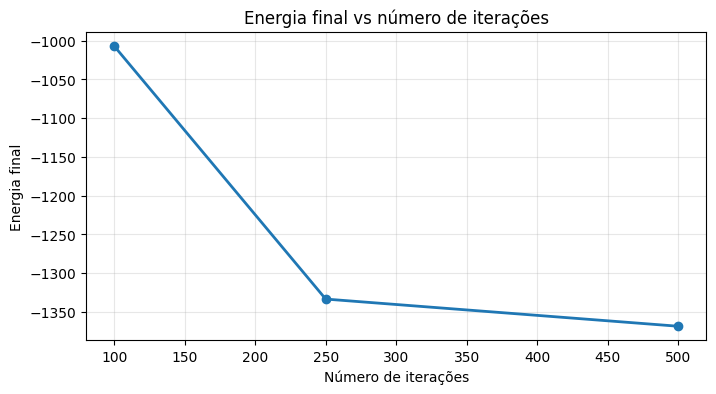

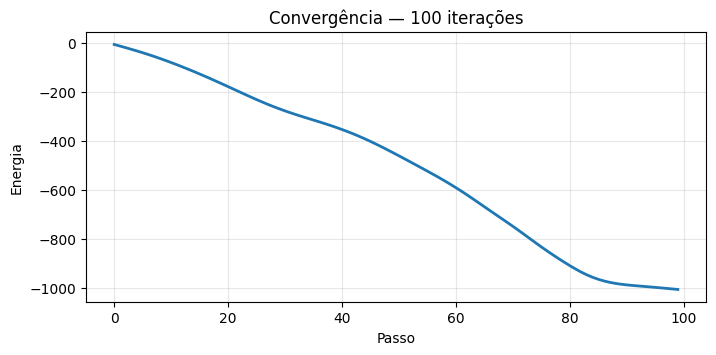

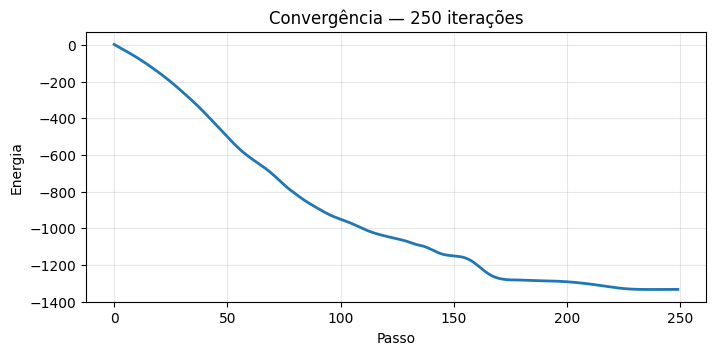

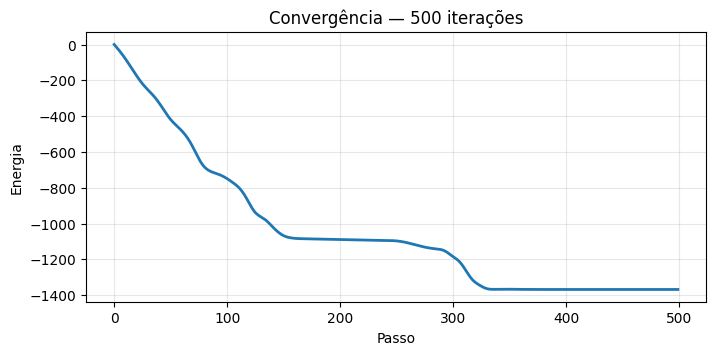

In [19]:

plt.figure(figsize=(8, 4))
plt.plot(df_steps["steps"], df_steps["energia_final"], marker="o", linewidth=2)
plt.title("Energia final vs número de iterações")
plt.xlabel("Número de iterações")
plt.ylabel("Energia final")
plt.grid(alpha=0.3)
plt.show()

for r in results_steps:
    plt.figure(figsize=(8, 3.5))
    plt.plot(r["energy_history"], linewidth=2)
    plt.title(f"Convergência — {r['steps']} iterações")
    plt.xlabel("Passo")
    plt.ylabel("Energia")
    plt.grid(alpha=0.3)
    plt.show()


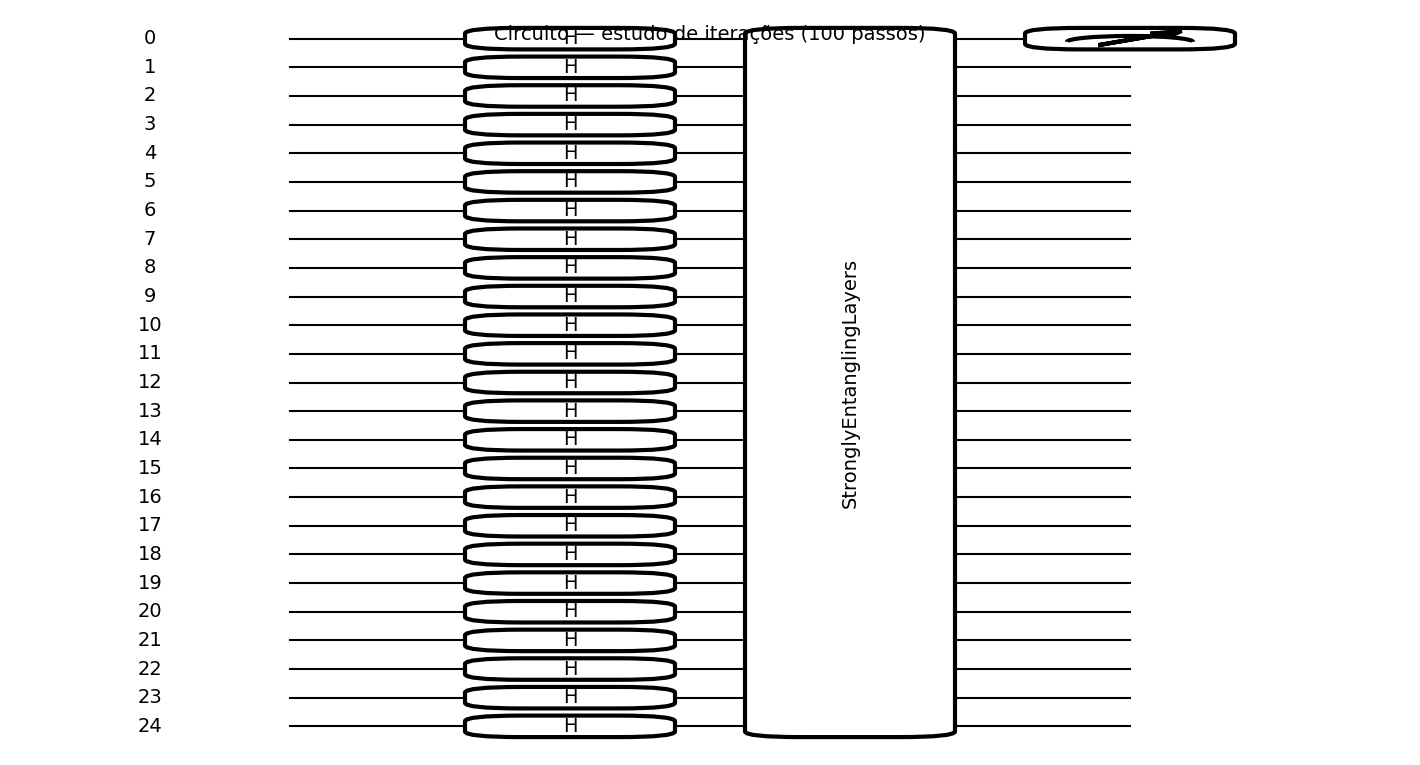

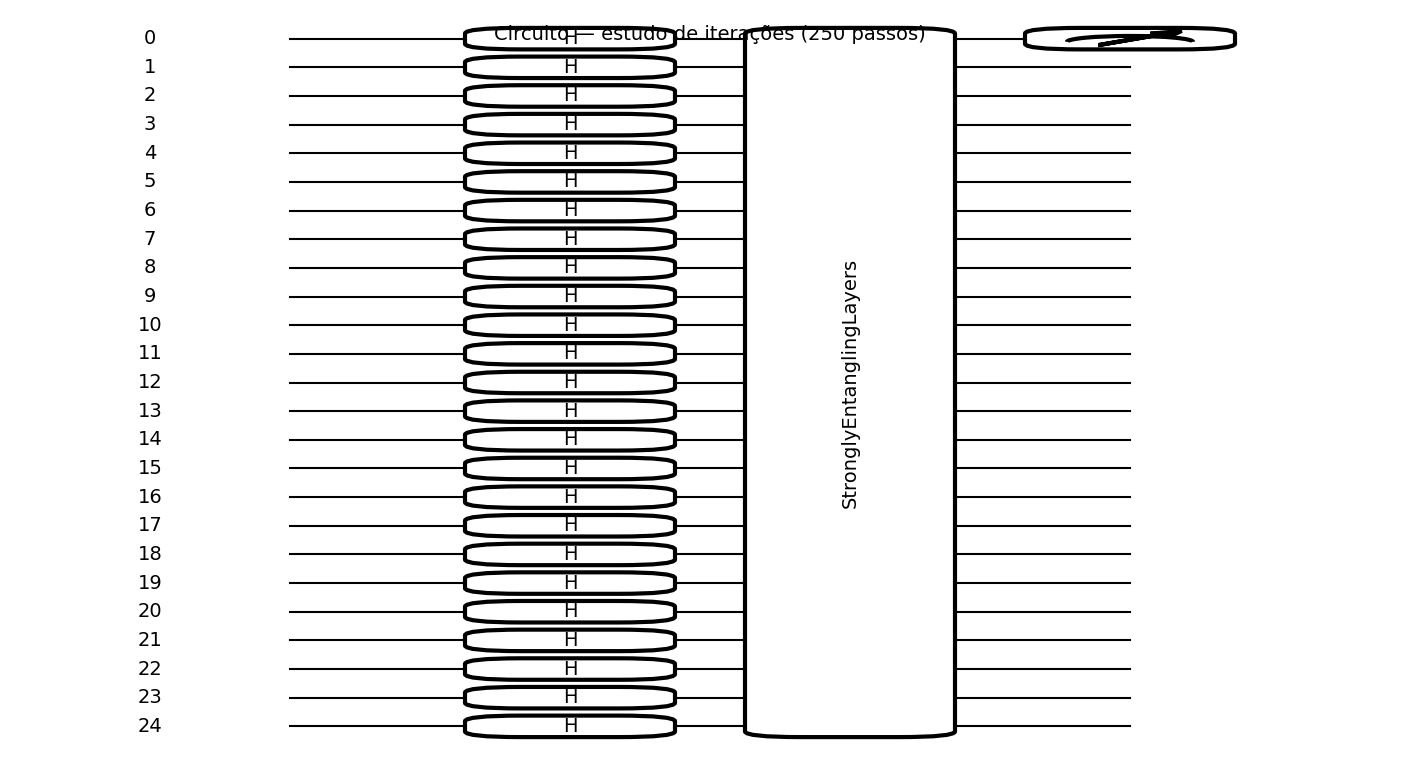

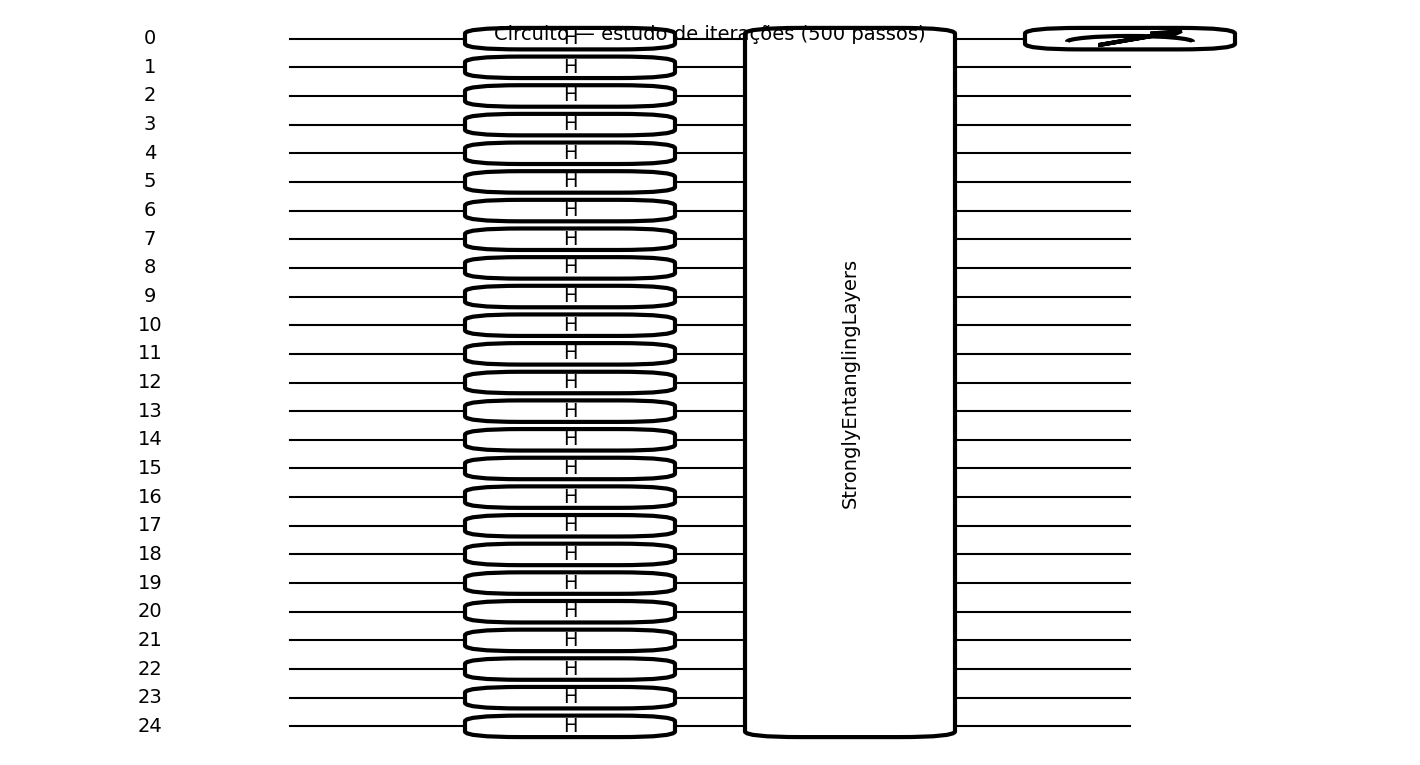

In [20]:

for steps in steps_grid:
    plot_circuit_example(
        weights_shape=(2, n_qubits, 3),
        title=f"Circuito — estudo de iterações ({steps} passos)",
        use_hadamard_init=True,
    )



### Como interpretar o estudo de iterações

- Se a curva cai e depois estabiliza sem produzir solução válida, isso sugere **convergência para um mínimo ruim**.
- Se a curva ainda cai fortemente no final, pode valer a pena aumentar o número de passos.
- Se a energia melhora, mas a solução continua inválida, “mais iterações” não está atacando a causa principal.



## 13) Estudo 3 — mudanças no Hamiltoniano

Aqui variamos o Hamiltoniano de três formas:

1. **Base**: \(A_{city}=A_{time}=A_{base}\)
2. **Penalidade reforçada**: penalidades maiores
3. **Distância normalizada**: parte de distância dividida por \(d_{max}\), o que muda a escala relativa entre objetivo e restrições
4. **Penalidades separadas**: reforçar cidade e tempo de forma diferente

Isso permite observar se o problema está no balanceamento entre custo e factibilidade.


In [21]:

hamiltonian_grid = [
    {
        "nome": "base",
        "A_city": A_base,
        "A_time": A_base,
        "distance_scale": 1.0,
    },
    {
        "nome": "penalidade_reforcada",
        "A_city": 2.0 * A_base,
        "A_time": 2.0 * A_base,
        "distance_scale": 1.0,
    },
    {
        "nome": "distancia_normalizada",
        "A_city": 4.0,
        "A_time": 4.0,
        "distance_scale": 1.0 / max(1e-12, d_max),
    },
    {
        "nome": "penalidades_separadas",
        "A_city": 2.0 * A_base,
        "A_time": 1.0 * A_base,
        "distance_scale": 1.0,
    },
]

results_hamiltonian = []

for cfg in hamiltonian_grid:
    print("Rodando Hamiltoniano:", cfg["nome"])
    res = run_vqe_experiment(
        D=D,
        A_city=cfg["A_city"],
        A_time=cfg["A_time"],
        distance_scale=cfg["distance_scale"],
        optimizer_name="adam",
        lr=0.02,
        n_layers=2,
        steps=250,
        restarts=5,
        use_hadamard_init=True,
        sample_shots=2048,
    )
    res["hamiltoniano"] = cfg["nome"]
    results_hamiltonian.append(res)

df_hamiltonian = pd.DataFrame([
    {
        "hamiltoniano": r["hamiltoniano"],
        "A_city": r["A_city"],
        "A_time": r["A_time"],
        "distance_scale": r["distance_scale"],
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    }
    for r in results_hamiltonian
])

df_hamiltonian


Rodando Hamiltoniano: base


/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Rodando Hamiltoniano: penalidade_reforcada
Rodando Hamiltoniano: distancia_normalizada
Rodando Hamiltoniano: penalidades_separadas


,hamiltoniano,A_city,A_time,distance_scale,energia_final,valido,distancia_decodificada,melhor_contagem
0,base,41.210775,41.210775,1.000000,-1333.445801,False,28.687785,530
1,penalidade_reforcada,82.421549,82.421549,1.000000,-2574.119141,False,28.687785,505
2,distancia_normalizada,4.000000,4.000000,0.121327,-133.458466,False,20.855920,541
3,penalidades_separadas,82.421549,41.210775,1.000000,-1737.142456,False,30.557852,1987


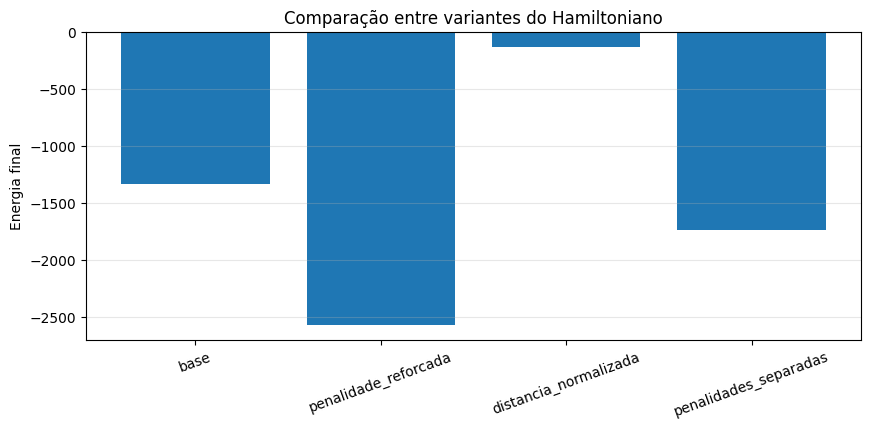

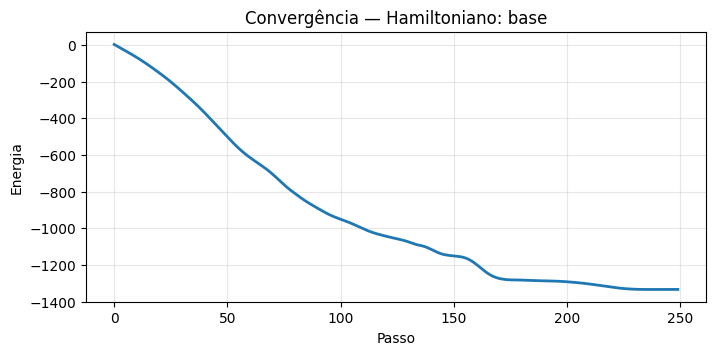

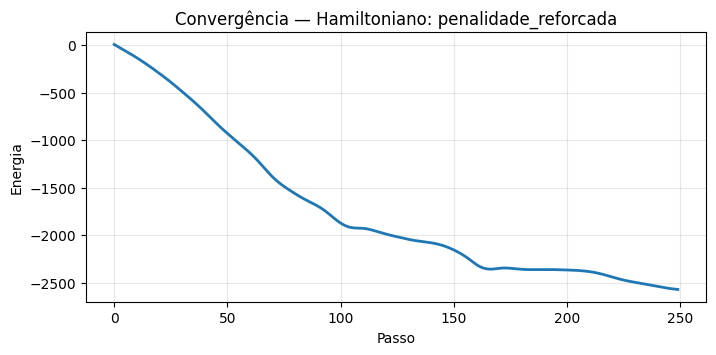

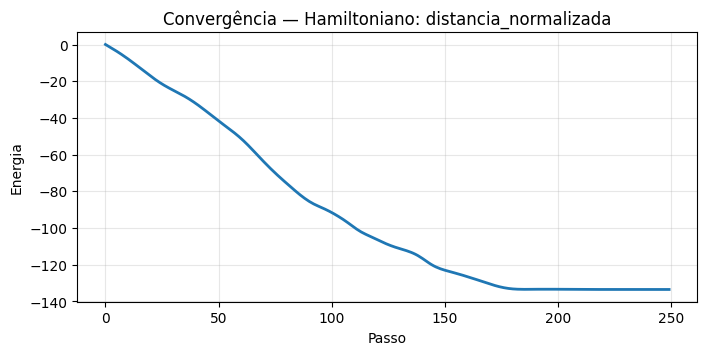

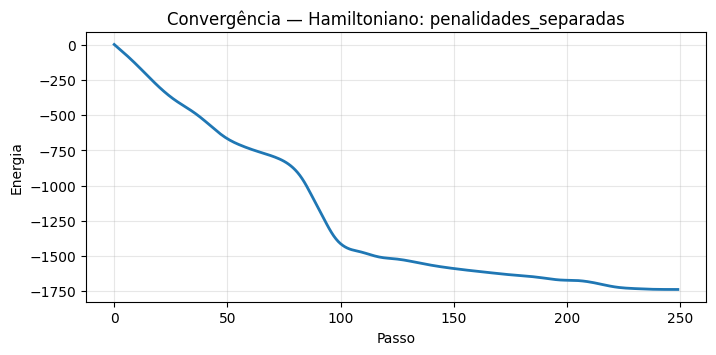

In [22]:

plt.figure(figsize=(10, 4))
plt.bar(df_hamiltonian["hamiltoniano"], df_hamiltonian["energia_final"])
plt.title("Comparação entre variantes do Hamiltoniano")
plt.ylabel("Energia final")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

for r in results_hamiltonian:
    plt.figure(figsize=(8, 3.5))
    plt.plot(r["energy_history"], linewidth=2)
    plt.title(f"Convergência — Hamiltoniano: {r['hamiltoniano']}")
    plt.xlabel("Passo")
    plt.ylabel("Energia")
    plt.grid(alpha=0.3)
    plt.show()


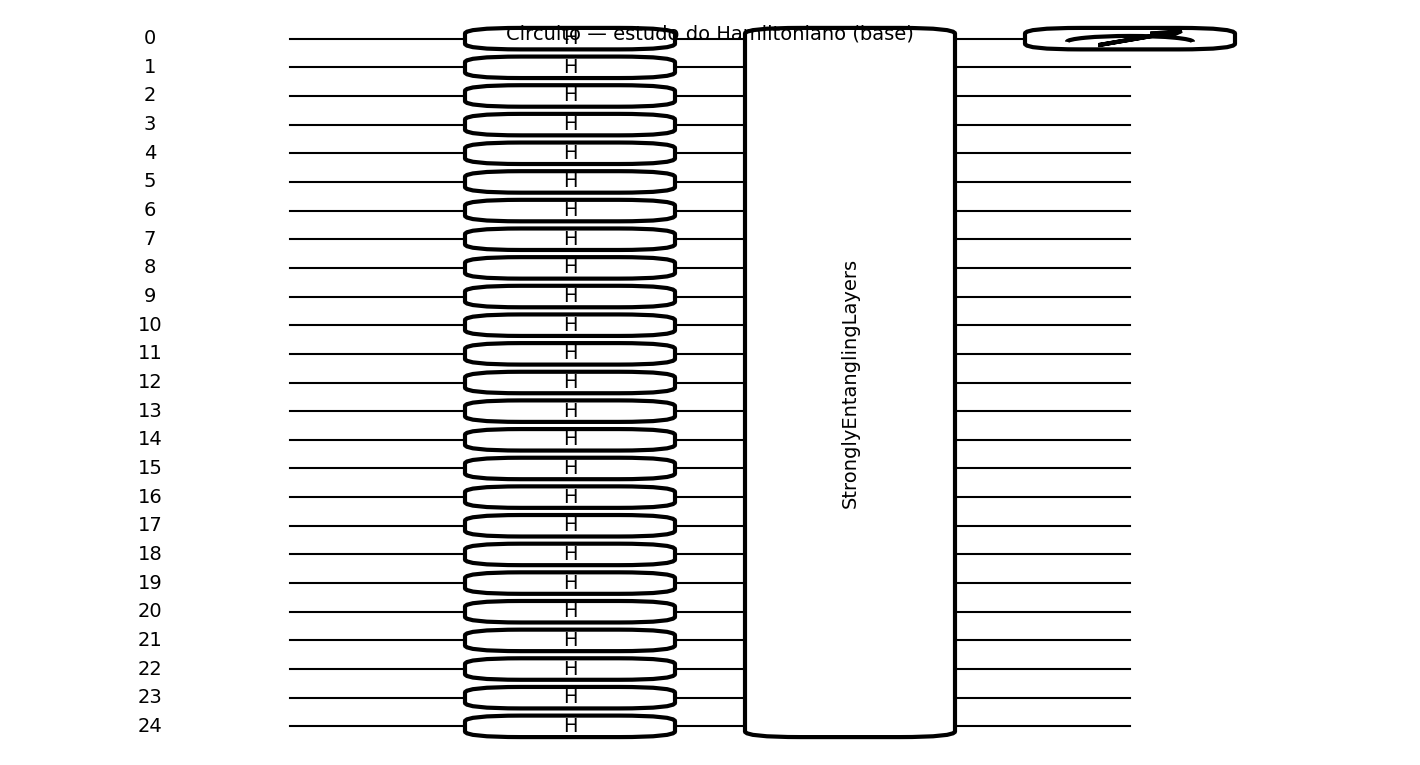

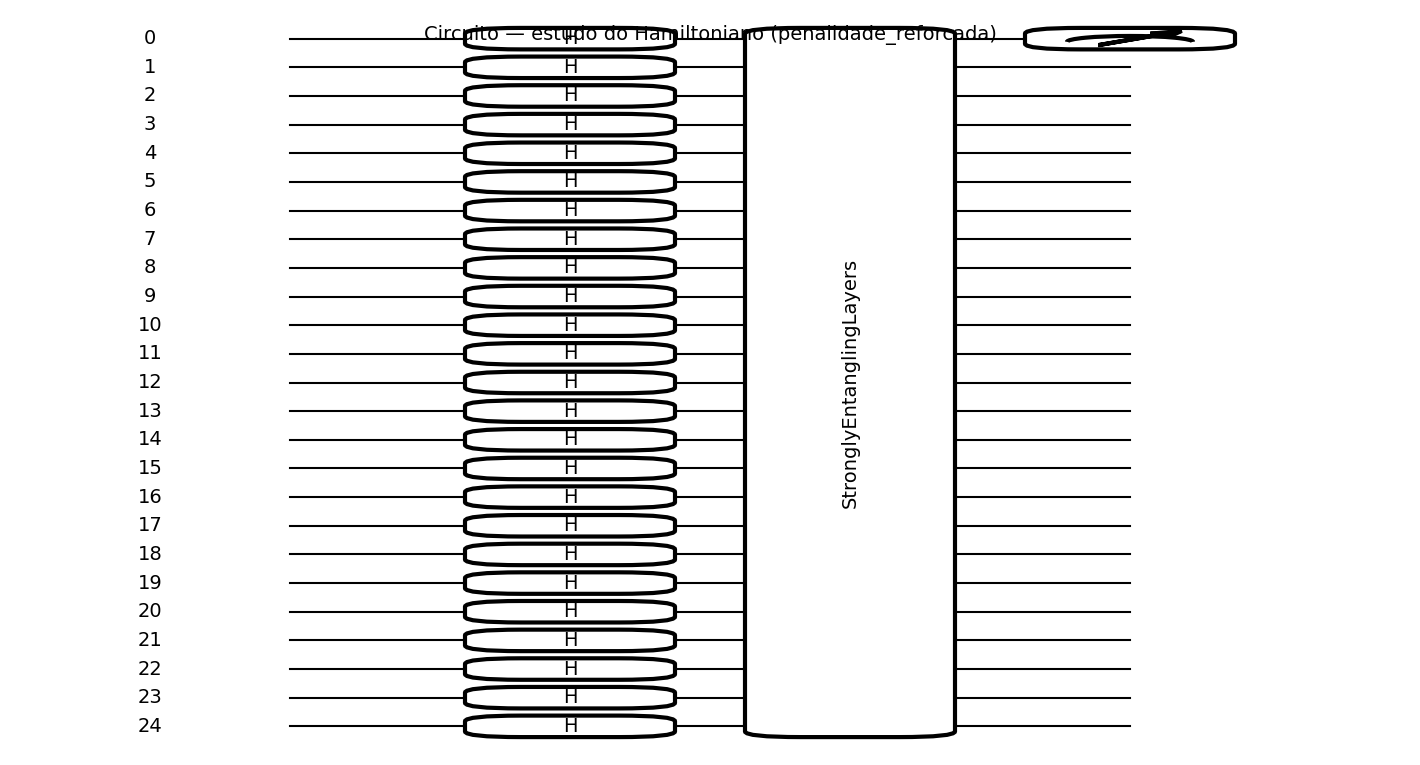

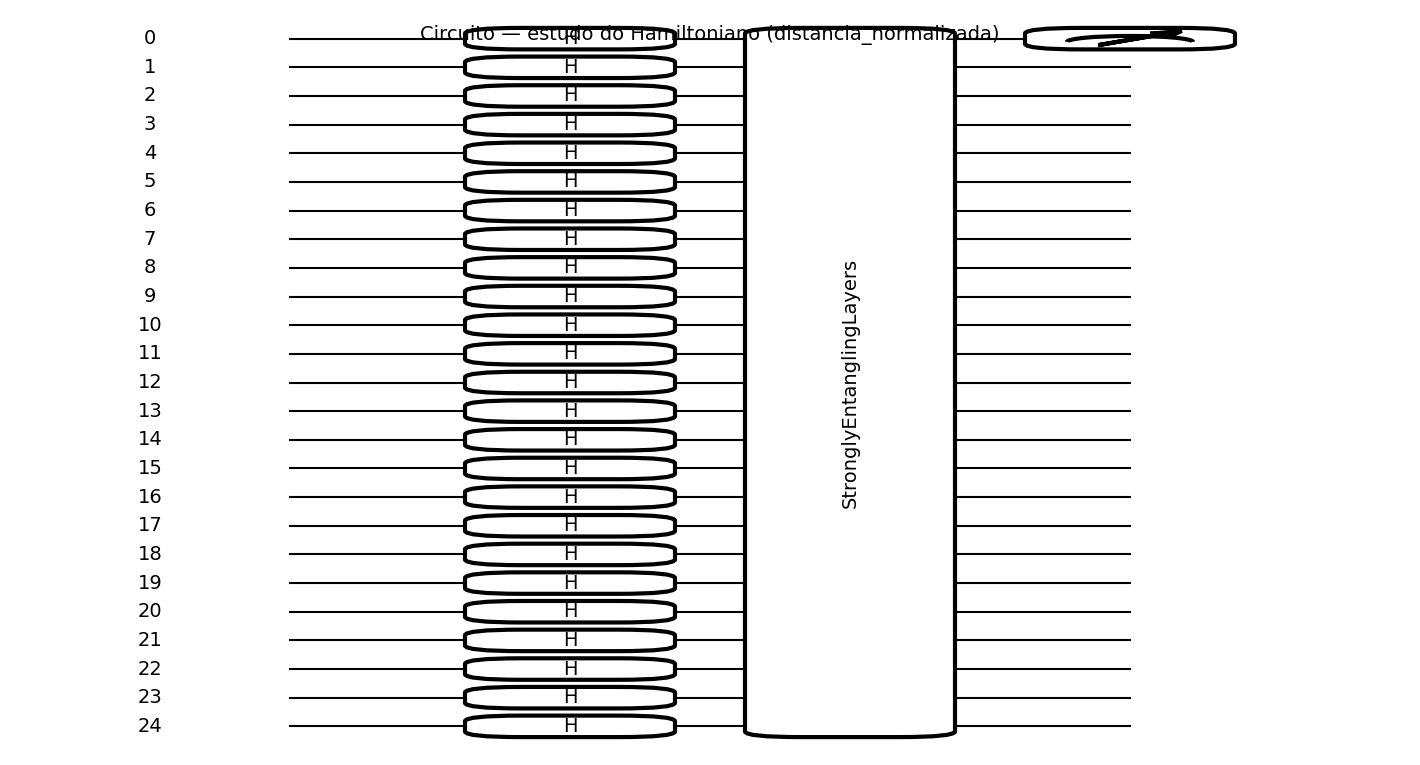

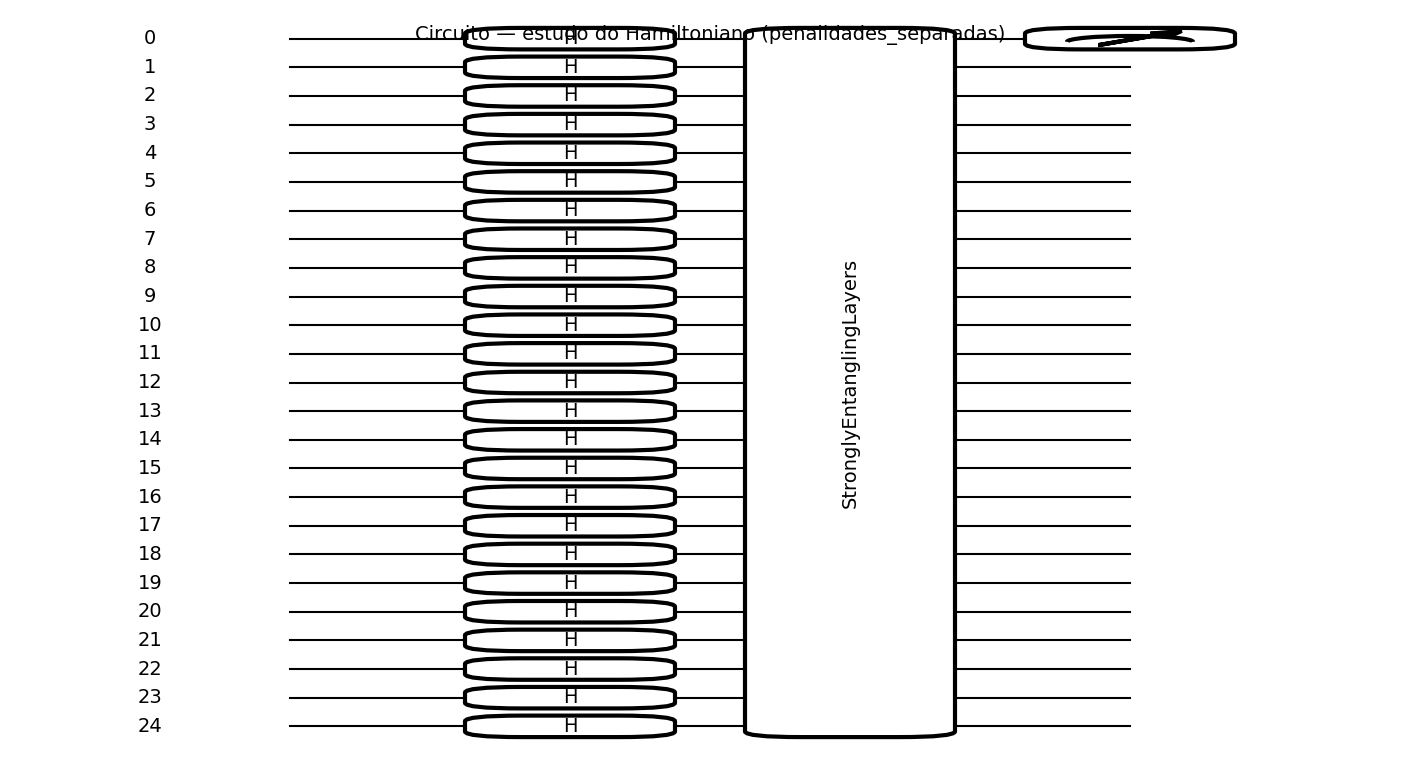

In [23]:

for cfg in hamiltonian_grid:
    plot_circuit_example(
        weights_shape=(2, n_qubits, 3),
        title=f"Circuito — estudo do Hamiltoniano ({cfg['nome']})",
        use_hadamard_init=True,
    )



### Como interpretar o estudo do Hamiltoniano

- Se aumentar as penalidades melhora a validade, então o Hamiltoniano anterior estava **subpenalizando** violações.
- Se penalidades maiores pioram tudo, pode estar havendo **domínio excessivo das restrições**, tornando a paisagem muito rígida.
- Se normalizar a distância ajuda, o problema era de **escala numérica**, não apenas de valor absoluto de \(A\).
- Se reforçar cidade e tempo separadamente muda o comportamento, o modelo está sofrendo mais em uma família de restrições do que na outra.



## 14) Resumo comparativo final

Esta tabela junta os melhores resultados dos três estudos.


In [24]:

summary_rows = []

for r in results_optimizer:
    summary_rows.append({
        "estudo": "otimizador",
        "config": f"{r['optimizer']} (lr={r['lr']})",
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    })

for r in results_steps:
    summary_rows.append({
        "estudo": "iteracoes",
        "config": f"{r['steps']} passos",
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    })

for r in results_hamiltonian:
    summary_rows.append({
        "estudo": "hamiltoniano",
        "config": r["hamiltoniano"],
        "energia_final": r["final_energy"],
        "valido": r["valid"],
        "distancia_decodificada": r["decoded_distance"],
        "melhor_contagem": r["best_count"],
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.sort_values(["estudo", "energia_final"]).reset_index(drop=True)


,estudo,config,energia_final,valido,distancia_decodificada,melhor_contagem
0,hamiltoniano,penalidade_reforcada,-2574.119141,False,28.687785,505
1,hamiltoniano,penalidades_separadas,-1737.142456,False,30.557852,1987
2,hamiltoniano,base,-1333.445801,False,28.687785,530
3,hamiltoniano,distancia_normalizada,-133.458466,False,20.855920,541
4,iteracoes,500 passos,-1368.496216,False,27.678977,524
5,iteracoes,250 passos,-1333.445801,False,22.056736,528
6,iteracoes,100 passos,-1007.073792,False,22.734552,898
7,otimizador,adam (lr=0.02),-1333.445801,False,28.687785,543
8,otimizador,rmsprop (lr=0.01),-1226.065063,False,33.024767,149
9,otimizador,sgd (lr=0.005),-901.068848,False,22.056736,366



## 15) Conclusões esperadas para o relatório

Ao escrever a análise, use uma lógica como esta:

1. **Correção metodológica:** havia inconsistência entre o circuito treinado e o circuito usado para decodificação; isso foi corrigido.
2. **Otimizador:** identificar qual método produziu menor energia e se isso se traduziu em maior factibilidade.
3. **Número de iterações:** verificar se o ganho de energia saturou ou se ainda havia progresso.
4. **Hamiltoniano:** observar se o balanceamento entre custo e restrições era o fator dominante.
5. **Interpretação física/computacional:**  
   - energia menor **não implica automaticamente** rota válida;  
   - em problemas combinatórios, o que importa é a combinação entre **energia, factibilidade e concentração da distribuição**;
   - se a melhor contagem do bitstring final continuar baixa, o estado ainda está muito espalhado.

## Observação importante
Se, mesmo após esses estudos, o VQE com ansatz genérico continuar falhando de forma sistemática, isso é um resultado válido: indica que, para essa formulação do TSP, um ansatz hardware-efficient simples pode ser inadequado. Nesse caso, uma continuação natural é comparar com um ansatz mais orientado a otimização combinatória, como um esquema inspirado em QAOA.
